In [110]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import TensorBoard
import datetime

log_dir = "logs/task1_fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1) # Record each epoch 


# Load data
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Flatten and normalise
X_train = X_train.reshape(-1, 28 * 28).astype("float32") / 255.0
X_test  = X_test.reshape(-1, 28 * 28).astype("float32") / 255.0


# Build deep MLP

In [111]:
def build_model(lr):
    model = keras.Sequential([
        layers.Dense(1024, activation="relu"),
        #layers.Dense(512, activation="relu"),
        #layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        # Try with different optimizers
        #optimizer=keras.optimizers.Adam(learning_rate=lr), # accuracy 98%
        #optimizer=keras.optimizers.SGD(learning_rate=lr), # accuracy 80%
        #optimizer=keras.optimizers.RMSprop(learning_rate=lr),# accuracy 98%
        #optimizer=keras.optimizers.Nadam(learning_rate=lr), # accuracy 98%
        optimizer=keras.optimizers.Adamax(learning_rate=lr), # accuracy 98%
        loss="sparse_categorical_crossentropy", 
        metrics=["accuracy"]
    )
    return model


In [112]:
model = build_model(lr=1e-3) # LR chosen after experimenting with exponential increments: each step multiplies previous LR by 10
                            # Tested LRs: 1e-6 → 1e-5 → 1e-4 → 1e-3 → 1e-2 → 1e-1
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test), # using test data directly
    epochs=10,
    batch_size=128,
    callbacks=[tensorboard_callback]
)
print("============================================================")
print("Learning rate: %.2e" % (model.optimizer.learning_rate))
print("Accuracy on test data: %.2f" % (model.evaluate(X_test, y_test)[1]))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9228 - loss: 0.2699 - val_accuracy: 0.9557 - val_loss: 0.1484
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.9654 - loss: 0.1206 - val_accuracy: 0.9687 - val_loss: 0.0998
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9766 - loss: 0.0806 - val_accuracy: 0.9758 - val_loss: 0.0819
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9834 - loss: 0.0588 - val_accuracy: 0.9797 - val_loss: 0.0687
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9872 - loss: 0.0450 - val_accuracy: 0.9789 - val_loss: 0.0676
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9909 - loss: 0.0328 - val_accuracy: 0.9804 - val_loss: 0.0624
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9933 - loss: 0.0254 - val_accuracy: 0.9826 - val_loss: 0.0578
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9955 - loss: 0.0185 - va

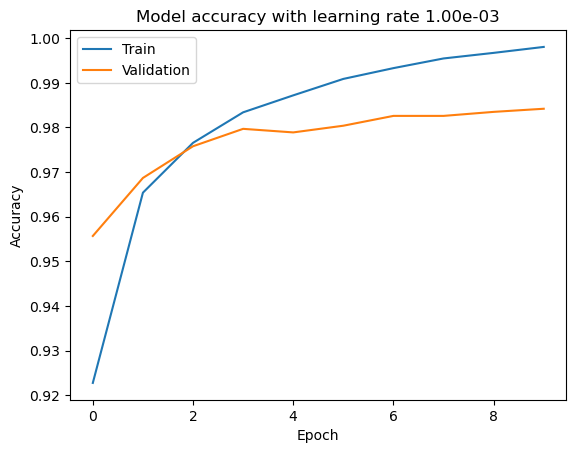

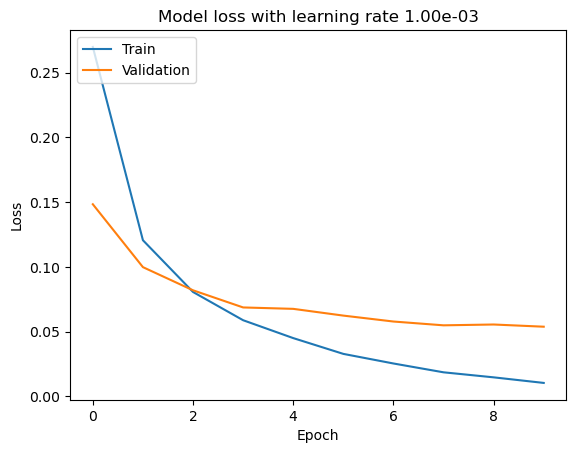

In [113]:
# Plot accuracy and loss
plt.figure()
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model accuracy with learning rate %.2e" % (model.optimizer.learning_rate))
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="upper left")
plt.show()

plt.figure()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model loss with learning rate %.2e" % (model.optimizer.learning_rate))
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="upper left")
plt.show()